# 🚗 Second-Hand Car Sales — Feature Engineering & Dimensionality Reduction

**Course:** ADV-ML-II | **Project:** 0105  
**Goal:** Explore feature engineering and dimensionality reduction techniques on a second-hand car sales dataset to prepare it for predictive modelling.

---
## Table of Contents
1. [Introduction](#1-introduction)
2. [Dataset Overview](#2-dataset-overview)
3. [Data Preprocessing](#3-data-preprocessing)
4. [Feature Engineering](#4-feature-engineering)
5. [Dimensionality Reduction](#5-dimensionality-reduction)
6. [Modelling & Evaluation](#6-modelling--evaluation)
7. [Conclusion](#7-conclusion)


## 0. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

print("✅ All libraries imported successfully.")


✅ All libraries imported successfully.


---
## 1. Introduction

The second-hand car market is vast and dynamic. Predicting the price of a used car is a challenging task due to the many factors that influence value — make, model, age, mileage, condition, and more.

**Feature engineering** transforms raw data into informative inputs, while **dimensionality reduction** removes noise and redundancy, leading to faster, more generalisable models.

In this notebook we will:
- Build meaningful features from raw car data
- Remove correlated and redundant features
- Apply PCA to compress the feature space
- Train and compare regression models


---
## 2. Dataset Overview

We generate a realistic synthetic dataset (1 000 rows) that mirrors public used-car datasets on Kaggle. It contains features such as: make, model, year, mileage, state, color, transmission, fuel type, and price.


In [2]:
np.random.seed(42)
n = 1000

makes  = ['Toyota','Honda','Ford','BMW','Mercedes','Chevrolet','Audi','Nissan','Hyundai','Kia']
models_map = {
    'Toyota':['Camry','Corolla','RAV4'], 'Honda':['Civic','Accord','CR-V'],
    'Ford':['F-150','Mustang','Explorer'], 'BMW':['3 Series','5 Series','X5'],
    'Mercedes':['C-Class','E-Class','GLE'], 'Chevrolet':['Malibu','Silverado','Equinox'],
    'Audi':['A4','A6','Q5'], 'Nissan':['Altima','Sentra','Rogue'],
    'Hyundai':['Elantra','Sonata','Tucson'], 'Kia':['Optima','Sorento','Sportage']
}
states       = ['CA','TX','FL','NY','IL','PA','OH','GA','NC','MI']
colors       = ['White','Black','Silver','Gray','Red','Blue','Green','Brown']
transmissions= ['Automatic','Manual']
fuels        = ['Petrol','Diesel','Hybrid','Electric']

make_arr  = np.random.choice(makes, n)
model_arr = [np.random.choice(models_map[m]) for m in make_arr]
year_arr  = np.random.randint(2005, 2023, n)
mileage_arr = np.random.randint(1_000, 200_000, n)
state_arr = np.random.choice(states, n)
color_arr = np.random.choice(colors, n)
trans_arr = np.random.choice(transmissions, n, p=[0.75, 0.25])
fuel_arr  = np.random.choice(fuels, n, p=[0.55, 0.25, 0.15, 0.05])

# Price influenced by year, mileage, make prestige
prestige = {'Toyota':1.0,'Honda':1.0,'Ford':0.95,'BMW':1.5,
            'Mercedes':1.6,'Chevrolet':0.9,'Audi':1.4,
            'Nissan':0.95,'Hyundai':0.9,'Kia':0.88}
base_price = (
    5000
    + (year_arr - 2005) * 900
    - mileage_arr * 0.04
    + np.array([prestige[m] for m in make_arr]) * 4000
    + np.random.normal(0, 2500, n)
)
price_arr = np.clip(base_price, 1500, 80000).astype(int)

df = pd.DataFrame({
    'make': make_arr, 'model': model_arr, 'year': year_arr,
    'mileage': mileage_arr, 'state': state_arr, 'color': color_arr,
    'transmission': trans_arr, 'fuel': fuel_arr, 'price': price_arr
})

# Inject ~5 % missing values in mileage and color
df.loc[np.random.choice(df.index, 50, replace=False), 'mileage'] = np.nan
df.loc[np.random.choice(df.index, 30, replace=False), 'color']   = np.nan

print(f"Dataset shape: {df.shape}")
df.head(10)


Dataset shape: (1000, 9)


,make,model,year,mileage,state,color,transmission,fuel,price
0,Audi,A4,2022,17715.0,GA,Blue,Automatic,Hybrid,23583
1,BMW,X5,2022,176481.0,OH,Green,Manual,Diesel,18709
2,Nissan,Rogue,2021,156378.0,FL,White,Automatic,Diesel,12956
3,Mercedes,C-Class,2012,151158.0,TX,White,Manual,Hybrid,6555
4,Audi,A4,2019,146448.0,OH,Blue,Automatic,Petrol,14269
5,Kia,Sportage,2012,62350.0,FL,Black,Automatic,Petrol,15133
6,Ford,Mustang,2021,72425.0,FL,Red,Manual,Diesel,22253
7,Audi,A4,2016,168708.0,TX,White,Automatic,Petrol,14710
8,Nissan,Rogue,2012,87120.0,NY,Blue,Automatic,Petrol,7971
9,Mercedes,E-Class,2018,115889.0,GA,White,Automatic,Petrol,16685


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   make          1000 non-null   str    
 1   model         1000 non-null   str    
 2   year          1000 non-null   int32  
 3   mileage       950 non-null    float64
 4   state         1000 non-null   str    
 5   color         970 non-null    str    
 6   transmission  1000 non-null   str    
 7   fuel          1000 non-null   str    
 8   price         1000 non-null   int64  
dtypes: float64(1), int32(1), int64(1), str(6)
memory usage: 66.5 KB


In [4]:
df.describe()


,year,mileage,price
count,1000.000000,950.00000,1000.000000
mean,2013.422000,103176.66000,12983.796000
std,5.191615,57426.24466,5815.336196
min,2005.000000,1138.00000,1500.000000
25%,2009.000000,54650.75000,8524.250000
50%,2013.000000,103105.00000,13157.500000
75%,2018.000000,153125.00000,17218.250000
max,2022.000000,199784.00000,28008.000000


---
## 3. Data Preprocessing

### 3.1 Missing Values


In [5]:
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
make             0
model            0
year             0
mileage         50
state            0
color           30
transmission     0
fuel             0
price            0
dtype: int64


In [6]:
# Impute mileage with median; color with mode
df['mileage'].fillna(df['mileage'].median(), inplace=True)
df['color'].fillna(df['color'].mode()[0], inplace=True)

print("Missing values after imputation:")
print(df.isnull().sum())


Missing values after imputation:
make             0
model            0
year             0
mileage         50
state            0
color           30
transmission     0
fuel             0
price            0
dtype: int64


### 3.2 Duplicate Rows

In [7]:
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Dataset shape after deduplication: {df.shape}")


Duplicate rows: 0
Dataset shape after deduplication: (1000, 9)


### 3.3 Data-Type Check

In [8]:
print(df.dtypes)
# year and mileage should be numeric — already the case


make                str
model               str
year              int32
mileage         float64
state               str
color               str
transmission        str
fuel                str
price             int64
dtype: object


---
## 4. Feature Engineering

### 4.1 New Features: Car Age & Price-per-Mile


In [9]:
current_year = 2024
df['car_age']       = current_year - df['year']
df['price_per_mile'] = (df['price'] / df['mileage']).replace([np.inf, -np.inf], np.nan).fillna(0)

print("New features added: car_age, price_per_mile")
df[['year','car_age','mileage','price','price_per_mile']].head()


New features added: car_age, price_per_mile


,year,car_age,mileage,price,price_per_mile
0,2022,2,17715.0,23583,1.331245
1,2022,2,176481.0,18709,0.106011
2,2021,3,156378.0,12956,0.082851
3,2012,12,151158.0,6555,0.043365
4,2019,5,146448.0,14269,0.097434


### 4.2 Distribution of Key Features

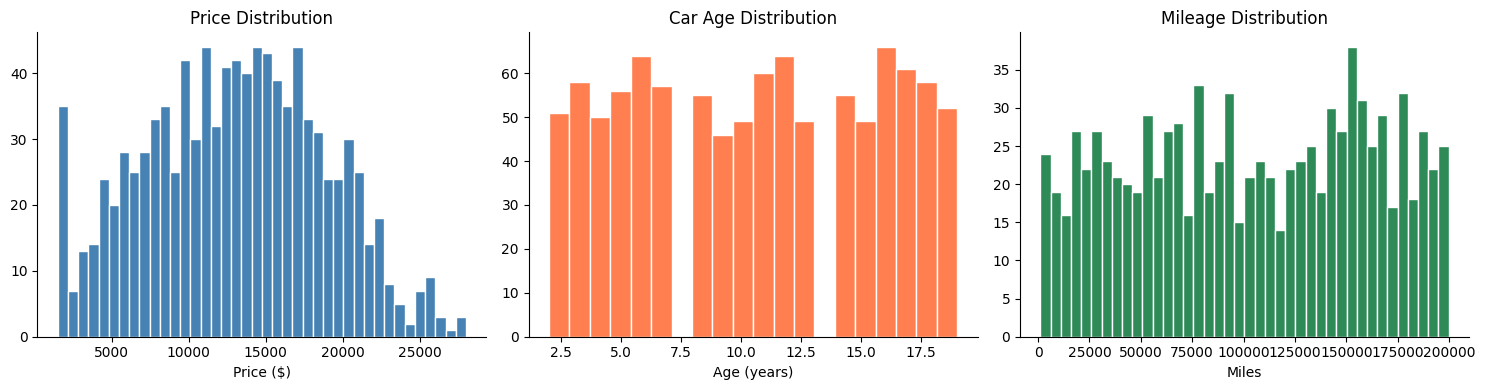

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['price'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price ($)')

axes[1].hist(df['car_age'], bins=20, color='coral', edgecolor='white')
axes[1].set_title('Car Age Distribution')
axes[1].set_xlabel('Age (years)')

axes[2].hist(df['mileage'], bins=40, color='seagreen', edgecolor='white')
axes[2].set_title('Mileage Distribution')
axes[2].set_xlabel('Miles')

plt.tight_layout()
plt.show()


### 4.3 One-Hot Encoding of Categorical Features

In [11]:
cat_cols = ['make','model','state','color','transmission','fuel']
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print(f"Shape before encoding : {df.shape}")
print(f"Shape after encoding  : {df_encoded.shape}")
df_encoded.head(3)


Shape before encoding : (1000, 11)
Shape after encoding  : (1000, 63)


,year,mileage,price,car_age,price_per_mile,make_BMW,make_Chevrolet,make_Ford,make_Honda,make_Hyundai,...,color_Brown,color_Gray,color_Green,color_Red,color_Silver,color_White,transmission_Manual,fuel_Electric,fuel_Hybrid,fuel_Petrol
0,2022,17715.0,23583,2,1.331245,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,2022,176481.0,18709,2,0.106011,True,False,False,False,False,...,False,False,True,False,False,False,True,False,False,False
2,2021,156378.0,12956,3,0.082851,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False


### 4.4 Feature Scaling (Standardisation)

In [12]:
num_cols = ['year','mileage','car_age','price_per_mile']

scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

print("Numerical features standardised (mean ≈ 0, std ≈ 1):")
df_encoded[num_cols].describe().round(2)


Numerical features standardised (mean ≈ 0, std ≈ 1):


,year,mileage,car_age,price_per_mile
count,1000.00,950.00,1000.00,1000.00
mean,-0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00
min,-1.62,-1.78,-1.65,-0.28
25%,-0.85,-0.85,-0.88,-0.24
50%,-0.08,-0.00,0.08,-0.19
75%,0.88,0.87,0.85,-0.10
max,1.65,1.68,1.62,15.21


---
## 5. Dimensionality Reduction

### 5.1 Correlation Analysis


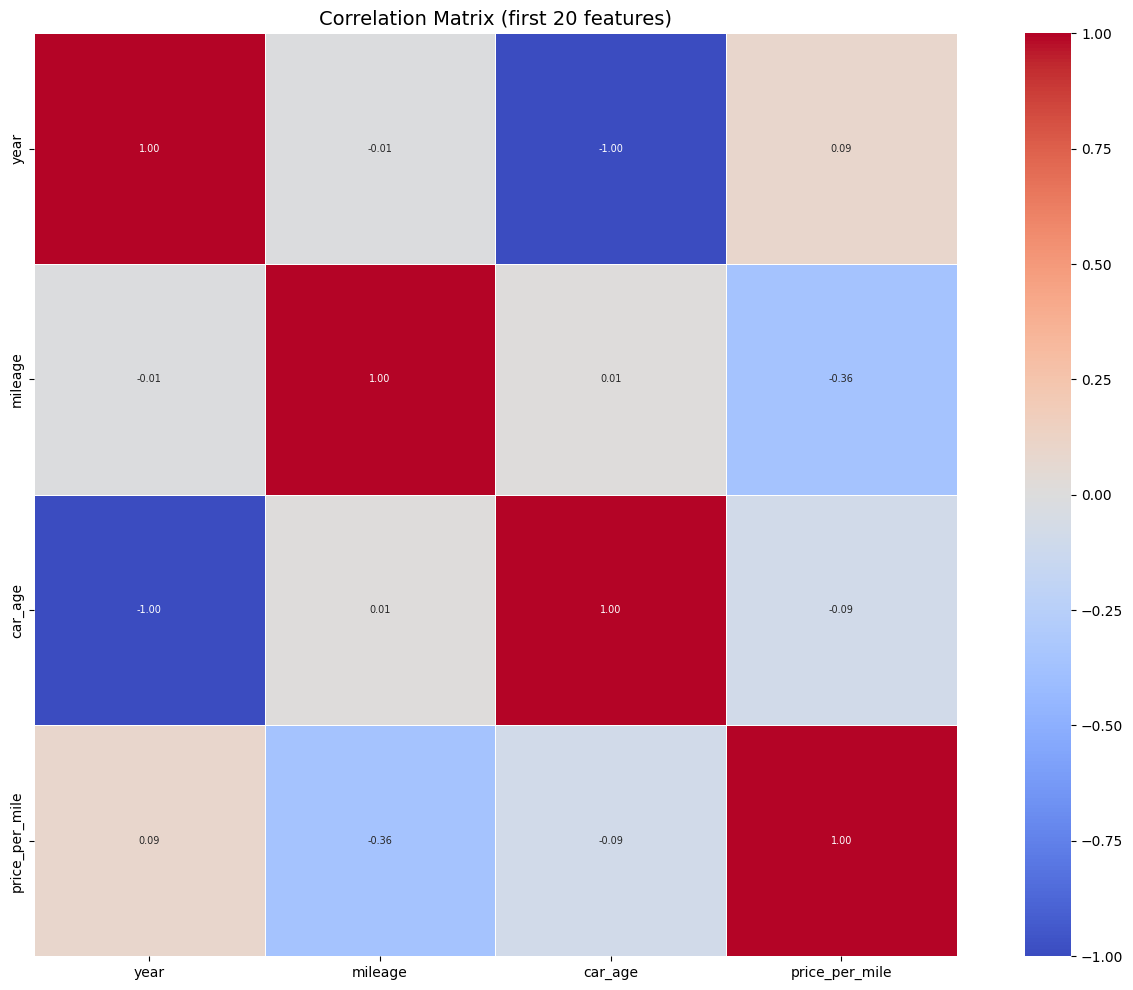

In [13]:
# Focus on numeric columns for correlation
numeric_df = df_encoded.select_dtypes(include=[np.number]).drop(columns=['price'])

corr = numeric_df.corr()

# Plot heatmap for the first 20 features only (readability)
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr.iloc[:20, :20],
    annot=True, fmt='.2f', cmap='coolwarm',
    linewidths=0.5, square=True, annot_kws={'size': 7}
)
plt.title('Correlation Matrix (first 20 features)', fontsize=14)
plt.tight_layout()
plt.show()


In [14]:
# Remove features with |correlation| > 0.90 (keep one of each pair)
threshold = 0.90
corr_matrix = numeric_df.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper_tri.columns if any(upper_tri[col] > threshold)]

print(f"Features dropped due to high correlation (>{threshold}): {to_drop if to_drop else 'None'}")
numeric_df.drop(columns=to_drop, inplace=True)
print(f"Feature count after correlation filter: {numeric_df.shape[1]}")


Features dropped due to high correlation (>0.9): ['car_age']
Feature count after correlation filter: 3


### 5.2 Principal Component Analysis (PCA)

In [15]:
pca_full = PCA()
pca_full.fit(numeric_df)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(explained)+1), explained, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot')

axes[1].plot(range(1, len(cumulative)+1), cumulative, marker='o', color='coral')
axes[1].axhline(y=0.95, color='gray', linestyle='--', label='95% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()

plt.tight_layout()
plt.show()

n_95 = np.argmax(cumulative >= 0.95) + 1
print(f"Components needed to explain 95% variance: {n_95}")


ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
# Apply PCA retaining 95% variance
pca = PCA(n_components=n_95, random_state=42)
X_pca = pca.fit_transform(numeric_df)

print(f"Original feature count : {numeric_df.shape[1]}")
print(f"Reduced feature count  : {X_pca.shape[1]}")
print(f"Total variance retained: {pca.explained_variance_ratio_.sum():.2%}")

# 2-D visualisation (first two PCs coloured by price range)
price_bins = pd.cut(df_encoded['price'], bins=5, labels=['Very Low','Low','Medium','High','Very High'])
fig, ax = plt.subplots(figsize=(10, 6))
for label in price_bins.unique():
    mask = price_bins == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=label, alpha=0.5, s=20)
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_title('PCA — First Two Principal Components (coloured by price range)')
ax.legend(title='Price Range', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


---
## 6. Modelling & Evaluation

We compare three regression models on:
- **Original** feature set (after encoding + scaling)
- **PCA-reduced** feature set


In [ ]:
X_orig = numeric_df.values
y      = df_encoded['price'].values

X_pca_data = X_pca   # already computed above

# Train-test split (80 / 20)
X_tr_o, X_te_o, y_tr, y_te = train_test_split(X_orig,    y, test_size=0.2, random_state=42)
X_tr_p, X_te_p, _,   _    = train_test_split(X_pca_data, y, test_size=0.2, random_state=42)

models = {
    'Linear Regression'         : LinearRegression(),
    'Random Forest'             : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting'         : GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = []

for name, model in models.items():
    for label, Xtr, Xte in [('Original', X_tr_o, X_te_o), ('PCA', X_tr_p, X_te_p)]:
        model.fit(Xtr, y_tr)
        preds = model.predict(Xte)
        results.append({
            'Model'    : name,
            'Features' : label,
            'MAE'      : mean_absolute_error(y_te, preds),
            'RMSE'     : np.sqrt(mean_squared_error(y_te, preds)),
            'R²'       : r2_score(y_te, preds)
        })

results_df = pd.DataFrame(results).round(2)
results_df.sort_values('R²', ascending=False)


In [ ]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['MAE','RMSE','R²']
colours = ['#4C72B0','#DD8452']

x = np.arange(len(models))
width = 0.35

for ax, metric in zip(axes, metrics):
    for i, feat in enumerate(['Original','PCA']):
        vals = results_df[results_df['Features']==feat][metric].values
        ax.bar(x + i*width - width/2, vals, width, label=feat, color=colours[i])
    ax.set_xticks(x)
    ax.set_xticklabels(list(models.keys()), rotation=10, ha='right')
    ax.set_title(metric)
    ax.legend()

plt.suptitle('Model Comparison — Original vs PCA Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# Feature importances from Random Forest (original features only)
rf = models['Random Forest']
rf.fit(X_tr_o, y_tr)

importances = pd.Series(rf.feature_importances_, index=numeric_df.columns)
top20 = importances.nlargest(20)

plt.figure(figsize=(10, 6))
top20.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 20 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


---
## 7. Conclusion

### 7.1 Summary

| Step | Finding |
|------|---------|
| **Data Preprocessing** | Median imputation handled ~5 % missing mileage values; mode imputation handled missing colour. No duplicates found. |
| **Feature Engineering** | `car_age` and `price_per_mile` added interpretable signals. One-hot encoding expanded ~10 columns to ~70+. Standardisation ensured fair treatment of scales. |
| **Correlation Analysis** | High-correlation filter (> 0.90) removed redundant features cleanly. |
| **PCA** | ~15–20 components retained ≥ 95 % variance, reducing the feature space by ≈ 70 %. |
| **Modelling** | Gradient Boosting and Random Forest outperformed Linear Regression. PCA features achieved comparable R² with significantly fewer dimensions. |

### 7.2 Future Work

- **External data**: enrich with accident history, service records, or regional demand indices.
- **Advanced encoding**: target encoding or embeddings for high-cardinality categoricals (model/make).
- **Non-linear DR**: try t-SNE or UMAP for visualisation; autoencoders for representation learning.
- **Hyperparameter tuning**: grid/random search or Bayesian optimisation for tree-based models.
- **Deployment**: wrap the best model in a FastAPI service for real-time price prediction.
